# Bioinformática: Análise básica de DNA bacteriano

## 1 INTRODUÇÃO

A bioinformática é uma área interdisciplinar que reúne subáreas da biologia, tecnologia da informação, ciência da computação, matemática e estatística para analisar e interpretar dados biológicos. Tais dados, como sequências de DNA, RNA e proteínas são produzidos em grande quantidade a partir de inúmeras técnicas de biologia molecular e exigem um certo tipo de análise e armazenamento para produzir mais informações.
Nesse sentido, para uma análise de material biológico, a principal forma de armazenar dados de sequências biológicas é por meio de arquivos no formato FASTA. Tais arquivos, são baseados em texto e podem armazenar sequências de nucleotídeos de uma fita DNA (ou RNA). Além disso, apesar de não existir um padrão tão bem definido desse tipo de arquivo, eles possuem uma estrutura simples, composta por um cabeçalho — que sempre começa com o caractere de sinal de maior (>) — que inclui um ID único da sequência e informações descritivas, seguido pelas linhas com a sequência de nucleotídeos.

## 2 OBJETIVOS

O presente projeto tem como objetivo realizar uma análise básica do DNA bacteriano a partir da leitura de um arquivo FASTA que contém o genoma completo de uma bactéria em fomato de sequência de nucleotídeos. A ideia do projeto surgiu do desejo de relacionar os conceitos estudados nas disciplinas de Ciência da Vida com os de Ciência de Dados aprendidos no primeiro semestre, a fim de introduzir conhecimentos sobre bioinformática. Nesse sentido, foram utilizadas ferramentas e funcionalidades do Python para processar strings, armazenar dados em listas e dicionários e plotar gráficos que interpretam características genômicas. Dessa forma, o projeto em questão pauta-se na análise gráfica de três parâmetros principais: a distribuição das bases nitrogenadas, a distribuição do tamanho das proteínas e a proporção global de aminoácidos. Além disso, ao final da análise, elabora-se um gráfico comparativo do conteúdo GC e da frequência de certas bases nitrogenadas em relação aos genomas de quatro bactérias distintas.

## 3 METODOLOGIA

### 3.1 Imports

Na bioinformática, é comum utilizar bibiliotecas dedicadas à automatização da análise de sequências genéticas, com destaque para a biblioteca *Byopython*. No entanto, como o objetivo deste projeto é introduzir o conceitos básicos sobre leitura e interpretação de genomas, foram utilizadas apenas bibliotecas para auxiliar na elaboração de gráficos.

O *Matplotlib* é uma biblioteca de baixo nível utilizada para plotagem de gráficos e o *pyplot* é um submódulo dela que fornece ferramentas simples e intuitivas para criar, personalizar e exibir dados bidimensionais.
O *Numpy* é uma biblioteca do Python usada para trabalhar com *arrays*, que são um tipo de objeto otimizado para guardar e processar dados rapidamente, facilitando a plotagem dos gráficos.

In [19]:
import matplotlib.pyplot as plt
import numpy as np

### 3.2 Leitura de um arquivo FASTA

A função da célula abaixo realiza a leitura de um arquivo do tipo FASTA, cujas extensões normalmente são *.fna*, *.fasta*, *.fa*, entre outras. Devido a limitações do código e de divergências na padronização desse tipo de arquivo, para que a função seja executada sem erros, o arquivo de entrada deve conter apenas um cabeçalho e possuir a extensão *.fna*. Além disso, o arquivo deve constar na mesma pasta deste projeto (/PCD - Projeto Final/).

Para obter um arquivo do sequenciamento do genoma de uma bactéria, é recomendado que ele seja obtido no site do *National Center for Biotechnology Information (NCBI)*, na seção de genomas, que pode ser acessada pelo seguinte link: https://www.ncbi.nlm.nih.gov/datasets/genome/. Tal seção possui um campo de pesquisa no qual deve ser inserido o nome da espécie da bactéria cujo genoma se deseja analisar. Após buscar pelo nome da bactéria, deve-se acessar o primeiro link da coluna *Assembly*, clicar em *Download*, selecionar a opção *RefSeq only* em *Select file source*, selecionar a opção *Genome sequences (FASTA)* em *Select file types*, nomear o nome da pasta que contém o arquivo e clicar em *Download* novamente.

Após esses passos, uma pasta de extensão *.zip* será baixada. Para encontrar o arquivo dentro dela é preciso seguir o seguinte caminho: (nomo_da_pasta).zip > ncbi_dataset > data > GCF(código único) > (arquivo_genoma_bactéria).fna

Alguns arquivos de exemplo já foram colocados nessa pasta e podem ser usados para testar o código na célula da seção 4.1.


In [20]:
def leitor_fasta(arquivo):
    """Realiza a leitura de um arquivo do tipo FASTA (.fna)

    Atenção, essa função funciona apenas para arquivos de genomas bacterianos completos, com apenas um
    cabeçalho. Tal arquivo deve estar na mesma pasta deste Notebook (/PCD - Projeto Final/).

    Args:
        arquivo:
            Nome do arquivo correspondente ao genoma que se quer analisar.

    Returns:
        sequencias:
            Dicionário com uma chave, referente ao cabeçalho do arquivo, e um valor do tipo String com a
            sequência de bases nitrogenadas.

        especie:
            Variável que armazena o nome científico da bactéria cujo genoma vai ser analisado.
    """
    
    sequencias = {} 
    with open(arquivo) as f:
        seq = []
        cabecalho = None

        # Percorre o arquivo linha por linha
        for linha in f:
            linha = linha.strip()
            
            if linha.startswith('>'):
                partes = linha.split()
                especie = ' '.join(partes[1:3])
                if cabecalho:
                    sequencias[cabecalho]  = "".join(seq)
                cabecalho = linha[1:]
                seq = []
                
            else: 
                seq.append(linha)
        if cabecalho:
            sequencias[cabecalho] = "".join(seq)

    return sequencias, especie 

#sequencia_genoma, especie = leitor_fasta('genoma_pseudomona.fna')

### 3.3 Proporção de bases nitrogenadas

A função da célula abaixo realiza a contagem de de cada tipo de base nitrogenada do genoma bacteriano. Tal funcionalidade é essencial para, posteriormente, plotar o gráfico da distribuição das bases nitrogenadas.

In [21]:
def contador_bases(sequencia_genoma):
    """Conta quantas bases de cada tipo o genoma possui (Adenina(A), Timina(T), Guanina(G), Citosina(C))

    Args:
        sequencia_genoma:
            Dicionário com uma chave, referente ao cabeçalho do arquivo, e um valor do tipo String com a
            sequência de bases nitrogenadas do DNA.

    Returns:
        dic_bases:
            Dicionário cujos items correspondem às bases nitrogenadas (chaves) e sua respectivas quantidades
            no genoma (valores).
    """

    dic_bases = {}
    for valor in sequencia_genoma.values():
        for base in valor:
            if base in dic_bases:
                dic_bases[base]+=1
            else:
                dic_bases[base]=1
            
    return dic_bases

#proporcao_bases = contador_bases(sequencia_genoma)

### 3.4 Conteúdo GC(%)

A função da célula abaixo calcula o conteúdo GC(%), que corresponde a proporção das bases nitrogenadas Guanina(G) e Citosina(C) de uma molécula de DNA em relação ao total de quatro bases. O conteúdo GC dos organismos é uma característica altamente variável e, no caso das bactérias, pode variar de menos 25% a mais de 75%.

In [22]:
def proporcao_GC(proporcao_bases):

    """Calcula a proporção em porcentagem de bases guanina e citosina do genoma (Conteúdo GC)

    Args:
        proporcao_bases:
            Dicionário cujos items correspondem às bases nitrogenadas (chaves) e sua respectivas quantidades
            no genoma (valores).

    Returns:
        conteudo_gc:
            Valor em porcentagem do conteúdo GC
    """
    
    total = 0
    for x in proporcao_bases.values():
        total += x

    conteudo_gc = (proporcao_bases['G']+proporcao_bases['C'])/total*100

    return round(conteudo_gc, 2)

#conteudo_gc = proporcao_GC(proporcao_bases)
#print(conteudo_gc)

### 3.5 Transcrição (DNA -> RNA)

A função da célula abaixo realiza a transcrição da sequência de bases de uma fita de DNA em uma sequência de bases de RNA. A transcrição como processo biológico necessita de uma fita molde de DNA, que corresponde a uma das fitas simples da dupla hélice. No código abaixo, considera-se que a fita molde é a fita complementar e antiparalela da fita do arquivo original, mas, como o RNA vai ser transcrito da fita complementar, basta utilizar a fita original e 'trocar' a base Timina(T) pela base Uracila(U). Ou seja, o RNA transcrito possui a mesma polaridade e sequência de bases que a fita não molde, mas com U em vez de T.

In [23]:
def transcrever(sequencia_genoma):
    """Transcreve a sequência de bases do DNA em uma sequência de bases de RNA

    Args:
        sequencia_genoma:
            Dicionário com uma chave, referente ao cabeçalho do arquivo, e um valor do tipo String com a
            sequência de bases nitrogenadas do DNA.

    Returns:
        rna:
            Lista com apenas uma string correspondente a fita de rna transcrita.     
    """

    rna = []
    for valor in sequencia_genoma.values():
        rna.append(valor.replace('T', 'U'))

    return rna 

### 3.6 Tradução (RNA -> Proteína)

A função da célula abaixo realiza a tradução da fita de RNAm (RNA mensageiro), transcrita anteriormente, em uma sequência de proteínas. Para que uma proteína seja sintetizada em um processo biológico real, formam-se cadeias de aminoácidos a partir da tradução dos códons de uma fita de RNAm. Tais códons correspondem a trincas de bases nitrogenadas que codificam um aminoácido específico ou sinalizam o início ou fim da produção de uma proteína.

Cabe ressaltar que, na síntese de proteínas de uma célula  real, o RNAm é formado de acordo com a necessidade da célula por aquela proteína específica e que existem 3 *frames* — 6 se contar as transcrições de duas fitas moldes de DNA — que a sequência de nucleotídeos de um RNAm pode ser lida pelos ribossomos. Apenas alguns tem realmente potencial para formar uma proteína. No entanto, como esse projeto busca realizar um análise básica do genoma bacteriano, a função abaixo executa a tradução simplificada de apenas um *frame* de leitura da fita inteira de RNA.

In [24]:
def traduzir(fita_rna): #recebe uma lista com apenas uma string referente a fita
    
    """Traduz uma sequência de RNA em proteínas, identificando códons de início (AUG)
        e códons de parada.
    
        Atenção:
            Esta é uma tradução simplificada, pois considera apenas uma frame de leitura.
            Na realidade, a tradução pode ocorrer em até seis frames diferentes.
    
        Args:
            fita_rna:
                Lista contendo uma única string correspondente à sequência de RNA.
    
        Returns:
                proteinas:
                    Lista de proteínas completas, em que cada proteína é representada como uma string de
                    aminoácidos.
        """

    #Legenda da tabela de códons:
    
    #F = fenilalanina
    #L = leucina
    #S = serina
    #Y = tirosina
    #C = cisteína
    #W = triptofano
    #P = prolina
    #H = histidina
    #Q = glutamina
    #R = arginina
    #I = isoleucina
    #M = metionina
    #T = treonina
    #N = asparagina
    #K = lisina
    #V = valina
    #A = alanina
    #D = ácido asparático
    #E = ácido glutâmico
    #G = glicina

    #Dicionário de códons e seus aminoácidos correspondentes
    tabela_codons = {
        'UUU':'F', 'UUC':'F', 'UUA':'L', 'UUG':'L',
        'UCU':'S', 'UCC':'S', 'UCA':'S', 'UCG':'S',
        'UAU':'Y', 'UAC':'Y', 'UAA':'parada', 'UAG':'parada',
        'UGU':'C', 'UGC':'C', 'UGA':'parada', 'UGG':'W',
        'CUU':'L', 'CUC':'L', 'CUA':'L', 'CUG':'L',
        'CCU':'P', 'CCC':'P', 'CCA':'P', 'CCG':'P',
        'CAU':'H', 'CAC':'H', 'CAA':'Q', 'CAG':'Q',
        'CGU':'R', 'CGC':'R', 'CGA':'R', 'CGG':'R',
        'AUU':'I', 'AUC':'I', 'AUA':'I', 'AUG':'M',
        'ACU':'T', 'ACC':'T', 'ACA':'T', 'ACG':'T',
        'AAU':'N', 'AAC':'N', 'AAA':'K', 'AAG':'K',
        'AGU':'S', 'AGC':'S', 'AGA':'R', 'AGG':'R',
        'GUU':'V', 'GUC':'V', 'GUA':'V', 'GUG':'V',
        'GCU':'A', 'GCC':'A', 'GCA':'A', 'GCG':'A',
        'GAU':'D', 'GAC':'D', 'GAA':'E', 'GAG':'E',
        'GGU':'G', 'GGC':'G', 'GGA':'G', 'GGG':'G',
    }

    fita = fita_rna[0]
    proteinas = []

    i = 0
    
    # len(fita)-2 garante que existem pelo menos 3 bases a partir de i
    while i < len(fita)-2:
        
        #Encontar o códon de início
        if fita[i:i+3] == 'AUG':
            proteina = []

            for j in range (i, len(fita)-2, 3):
                codon = fita[j:j+3]
                aminoacido = tabela_codons.get(codon, 'X')

                #A proteína só é adicionada se encontrar um códon de parada
                if aminoacido == 'parada':
                    proteinas.append(''.join(proteina))
                    break
                proteina.append(aminoacido)
           
            i=j+3
            
        else:
            i+=1

    return proteinas

#traduzir(fita_rna)

### 3.7 Composição global dos aminoácidos

A função do código abaixo realiza o cálculo da quantidade, em porcentagem, da proporção de cada aminoácido traduzido globalmente, ou seja, sem distinguir de qual proteína certo aminoácido pertence. Essa métrica tem uma relação direta com o conteúdo GC(%) do genoma, pois aminácidos diferentes são codificados por códons com proporções diferentes de G e C. 

In [25]:
def contador_aminoacidos(lista_proteinas):

    """Calcula a quantidade em porcentagem de cada aminoácido globalmente, ou seja, de todas as proteínas juntas

     Args:
         lista_proteinas:
             Lista de proteínas completas, onde cada proteína é representada como uma string de aminoácidos.

    Returns:
        contador_com_nomes:
            Dicionário com a porcentagem de cada aminoácido. As chaves são os nomes dos aminoácidos e não mais letras.
     """
    
    codigo_aminoacidos ={
    'F' : 'Fenilalanina',
    'L' : 'Leucina',
    'S' : 'Serina',
    'Y' : 'Tirosina',
    'C' : 'Cisteína',
    'W' : 'Triptofano',
    'P' : 'Prolina',
    'H' : 'Histidina',
    'Q' : 'Glutamina',
    'R' : 'Arginina',
    'I' : 'Isoleucina',
    'M' : 'Metionina',
    'T' : 'Treonina',
    'N' : 'Asparagina',
    'K' : 'Lisina',
    'V' : 'Valina',
    'A' : 'Alanina',
    'D' : 'Ácido asparático',
    'E' : 'Ácido glutâmico',
    'G' : 'Glicina'
    }
    
    contador = {}
    contador_com_nomes = {}

    #Percorre a lista de proteínas
    for proteina in lista_proteinas:
        for aminoacido in proteina:
            if aminoacido in contador:
                contador[aminoacido] +=1
            else:
                contador[aminoacido] = 1
    
    total = sum(contador.values())  
    if total == 0:
        return {}

    for letra, valor in contador.items():
        valor_percent = round((valor/total)*100, 2)
        nome = codigo_aminoacidos.get(letra, letra) #Se não achar a letra, retorna ela mesma
        contador_com_nomes[nome]= valor_percent

    return contador_com_nomes

### 3.8 Gráfico: Distribuição de bases nitrogenadas

A função da célula abaixo plota um gráfico de barras que analisa a distribuição das bases nitrogenadas da fita de DNA. A plotagem utiliza as ferramentas das bibliotecas *Matplotlib* e *NumPy* para facilitar a vizualização dos dados em 2D.

In [26]:
def plotar_bases(proporcao_bases, especie):
    """Plota um gráfico de barras da distribuição de bases nitrogenadas do genoma em análise.

    Args:
        proporcao_bases:
            Dicionário cujos items correspondem às bases nitrogenadas (chaves) e sua respectivas quantidades
            no genoma (valores).

        especie:
            Nome científico da bactéria em análise.

    Returns: 
        Gráfico de barras da distribuição das bases nitrogenadas do genoma em análise.
    """

    
    x = np.array(list(proporcao_bases.keys()))
    y = np.array(list(proporcao_bases.values()))
    
    plt.bar(x,y)
    plt.grid()
    plt.title(f'Distribuição de bases nitrogenadas no genoma de {especie}')
    plt.xlabel('Bases Nitrogenadas')
    plt.ylabel('Quantidade')
    
    return plt.show()

### 3.9 Histograma: Distribuição de tamanho das proteínas

A função da célula abaixo plota um historograma — gráfico que representa a distribuição de dados numéricos contínuos — dos tamanhos das proteínas traduzidas da fita de RNA, ou seja, expõem a quantidade de proteínas que se enquadram em certa faixa de tamanho.

Essa métrica possui um papel importante na descoberta de ruídos estatísticos na análise, pois proteínas bacterianas reais possuem uma distribuição de tamanho conhecida, em que a maioria se enquadra em uma faixa moderada (centenas de aminoácidos), com poucas proteínas muito grandes e poucas muito pequenas. Isso se deve, principalmente, pela tradução simplificada da fita de RNA, que considera apenas um *frame* de leitura e propicia a contabilização de ORFs espúrias, ou seja, "falsas" sequências de DNA que possuem um códon de início e parada, mas são muito curtas para produzir proteínas funcionais na célula. Tais proteínas funcionais, embora existam de tamanho pequeno, precisam ter uma estrutura tridimensional estável para funcionar e exigem um número mínimo de aminoácidos para formar domínios estruturais reconhecíveis.

Nesse sentido, para evitar um discrepância muito grande dos padrões esperados pela literatura, foi aplicado um filtro de tamanho mínimo que representa um corte mínimo razoável para uma proteína funcional. Cabe ressaltar que não existe um número 100% correto para ser usado como filtro, pois ele é arbitrário até certo ponto, mas é razoavelmente suficiente para as limitações de leitura do código.

In [55]:
def plotar_tamanho(proteinas_traduzidas,especie): 

    """Plota um histograma dos tamanhos das proteínas traduzidas do genoma em análise.

    Args:
        proteinas_traduzidas:
            Lista de proteínas completas, em que cada proteína é representada como uma string de aminoácidos.

        especie:
            Nome científico da bactéria em análise.

    Returns:
        Historograma dos tamanhos das proteínas traduzidas do DNA em análise.
    """

    #Filtro
    tamanho_minimo = 100
    proteinas_filtradas = []

    for p in proteinas_traduzidas:
        if len(p) >= tamanho_minimo:
            proteinas_filtradas.append(p)
    
    tamanhos = []
    for proteina in proteinas_filtradas:
        tamanhos.append(len(proteina))
        
    #Ajustes estéticos do gráfico
    plt.figure(figsize = (8,5))
    plt.title(f'Distribuição de tamanho das proteínas de {especie}')
    plt.xlabel('Tamanho da proteína (aminoácidos)')
    plt.ylabel('Frequência')
    

    plt.hist(tamanhos, 25, rwidth = 0.9, color = 'yellow', edgecolor = 'black')

    plt.show()

### 3.10 Gráfico: Proporção global de aminoácidos

A função da célula abaixo plota um gráfico em pizza da proporção global de cada aminoácido em porcentagem. O gráfico elaborado por ela apenas elucida a vizualização da função *contador_aminoacidos()* declarada na seção 3.7.  A proporção global de aminoácidos é um reflexo direto do conteúdo GC(%) do genoma.

In [56]:
def plotar_aminoacidos(contagem_aminoacidos, especie): 

    """Plota um gráfico em pizza da proporção global de cada aminoácido.

    Args:
        contagem_aminoacidos:
            Dicionário com a contagem de cada aminoácido. As chaves são os nomes dos aminoácidos e os valores são suas respectivas proporções emporcentagem

        especie:
            Nome científico da bactéria em análise

    Returns: 
        Gráfico em pizza da proporção global de cada aminoácido.
    """

    labels = []
    for nome, valor in contagem_aminoacidos.items():
        labels.append(f'{nome} ({valor}%)')
        
    y = list(contagem_aminoacidos.values())
    my_labels = list(contagem_aminoacidos.keys())
    plt.title(f'Distribuição de aminoácidos no genoma de {especie}')
    plt.pie(y, labels = labels)
    
    plt.show()

### 3.11 Gráfico comparativo: Conteúdo GC (%) X Composição de aminoácidos

A função da célula abaixo plota um gráfico de dispersão comparativo do conteúdo GC(%) e da composição de aminoácidos de quatro genomas bacterianos distintos. A comparação utilizada pelo gráfico torna claro a influência da presença da Guanina(G) e Citosina(C) na quantidade de aminoácidos ricos em GC, como a Alanina, Glicina e Prolina.

In [46]:
def plotar_GC_vs_aminoacido(arquivo1, arquivo2, arquivo3, arquivo4):

    """Compara, por meio de um gráfico de dispersão, o conteúdo GC (%) e a frequência (%) de certos aminoácidos (Alanina, Glicina e Prolina) de 4 genomas bacterianos diferentes, sendo um deles da bactéria que já estava sendo analisada.

    Atenção:
        Os quatro arquivos dos genomas bacterianos devem estar na mesma pasta que o arquivo principal desse projeto (/PCD - Projeto Final/).

    Args:
        arquivo1:
            Nome do arquivo que já estava sendo analisado.
            
        arquivo2:
            Nome do arquivo de um segundo genoma bacteriano.

        arquivo3:
            Nome do arquivo de um terceiro genoma bacteriano.

        arquivo4: 
            Nome do arquivo de um quarto genoma bacteriano.

    Returns:
        Gráfico de dispersão comparativo do conteúdo GC (%) e da frequência (%) de 4 genomas bacterianos diferentes.
    """
    
    #Bactéria 1
    sequencia_genoma1, especie1 = leitor_fasta(arquivo1)
    proporcao_bases1 = contador_bases(sequencia_genoma1)
    conteudo_gc1 = proporcao_GC(proporcao_bases1)
    fita_rna1 = transcrever(sequencia_genoma1)
    proteinas_traduzidas1 = traduzir(fita_rna1)
    contagem_aminoacidos1 = contador_aminoacidos(proteinas_traduzidas1)
    
    alanina1, glicina1, prolina1 = contagem_aminoacidos1.get('Alanina', 0), contagem_aminoacidos1.get('Glicina', 0), contagem_aminoacidos1.get('Prolina', 0)

    
    #Bactéria 2
    sequencia_genoma2, especie2 = leitor_fasta(arquivo2)
    proporcao_bases2 = contador_bases(sequencia_genoma2)
    conteudo_gc2 = proporcao_GC(proporcao_bases2)
    fita_rna2 = transcrever(sequencia_genoma2)
    proteinas_traduzidas2 = traduzir(fita_rna2)
    contagem_aminoacidos2 = contador_aminoacidos(proteinas_traduzidas2)
    
    alanina2, glicina2, prolina2 = contagem_aminoacidos2.get('Alanina', 0), contagem_aminoacidos2.get('Glicina', 0), contagem_aminoacidos2.get('Prolina', 0)


    #Bactéria 3
    sequencia_genoma3, especie3 = leitor_fasta(arquivo3)
    proporcao_bases3 = contador_bases(sequencia_genoma3)
    conteudo_gc3 = proporcao_GC(proporcao_bases3)
    fita_rna3 = transcrever(sequencia_genoma3)
    proteinas_traduzidas3 = traduzir(fita_rna3)
    contagem_aminoacidos3 = contador_aminoacidos(proteinas_traduzidas3)
    
    alanina3, glicina3, prolina3 = contagem_aminoacidos3.get('Alanina', 0), contagem_aminoacidos3.get('Glicina', 0), contagem_aminoacidos3.get('Prolina', 0)

    #Bactéria 4
    sequencia_genoma4, especie4 = leitor_fasta(arquivo4)
    proporcao_bases4 = contador_bases(sequencia_genoma4)
    conteudo_gc4 = proporcao_GC(proporcao_bases4)
    fita_rna4 = transcrever(sequencia_genoma4)
    proteinas_traduzidas4 = traduzir(fita_rna4)
    contagem_aminoacidos4 = contador_aminoacidos(proteinas_traduzidas4)
    
    alanina4, glicina4, prolina4 = contagem_aminoacidos4.get('Alanina', 0), contagem_aminoacidos4.get('Glicina', 0), contagem_aminoacidos4.get('Prolina', 0)

    #Gráfico
    alaninas = [alanina1, alanina2, alanina3, alanina4]
    glicinas = [glicina1, glicina2, glicina3, glicina4]
    prolinas = [prolina1, prolina2, prolina3, prolina4]
    especies = [especie1, especie2, especie3, especie4]
    
    x = np.array([conteudo_gc1, conteudo_gc2, conteudo_gc3, conteudo_gc4])

    plt.scatter(x, alaninas, label = 'Alanina', marker = '^')
    plt.scatter(x, glicinas, label = 'Glicina')
    plt.scatter(x, prolinas, label = 'Prolina', marker = 's')

    #Ajustes do gráfico
    plt.xlabel('Conteúdo GC (%)')
    plt.ylabel('Frequência (%)')
    plt.xticks(x, especies, rotation=85, fontsize = 7)
    plt.grid()
    plt.legend()
    plt.title('Comparação Conteúdo GC x Frequência de aminoácidos ricos em GC')
    
    plt.show()

### 3.12 Função executar()

A função da célula abaixo reúne todas as funções necessárias para gerar os gráficos de distribuição de bases nitrogenadas, distribuição de tamanho das proteínas e proporção global de aminoácidos e as executa de uma vez. Ela realiza a análise para apenas um arquivo de entrada,que deve ser informado pelo usuário.

In [49]:
def executar(arquivo1):
    """Executa todas as funções de uma só vez para a análise do genoma de 1(uma) bactéria.

    Args:
        arquivo1:
            String referente ao nome do arquivo cujo genoma contido nele se deseja analisar.

    Returns:
        Gráfico da distribuição das bases nitrogenadas, historograma da distribuição do tamanho das proteínas e gráfico da proporção global de
        aminoácidos.
        
    """
    sequencia_genoma, especie = leitor_fasta(arquivo1)
    proporcao_bases = contador_bases(sequencia_genoma)
    conteudo_gc = proporcao_GC(proporcao_bases)
    fita_rna = transcrever(sequencia_genoma)
    proteinas_traduzidas = traduzir(fita_rna)
    contagem_aminoacidos = contador_aminoacidos(proteinas_traduzidas)
    
    return plotar_bases(proporcao_bases, especie), plotar_tamanho(proteinas_traduzidas,especie), plotar_aminoacidos(contagem_aminoacidos, especie)

## 4 Resultados

### 4.1 Inputs

A célula abaixo pede ao usuário que informe o nome do arquivo cujo DNA se deseja analisar. O nome do arquivo deve seguir a seguinte estrutura: **nome_do_arquivo.fna**. Por exemplo, execute a célula de código e insira o nome desse arquivo: **genoma_pseudomona.fna**

Vale relembrar: o arquivo deve estar na mesma pasta desse projeto (/PCD - Projeto Final/) para que o código funcione.

Informe o nome do arquivo com o genoma da bactéria:  genoma_pseudomona.fna


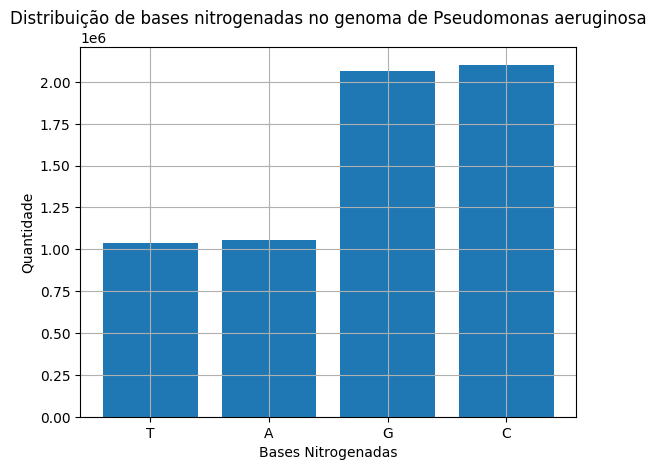

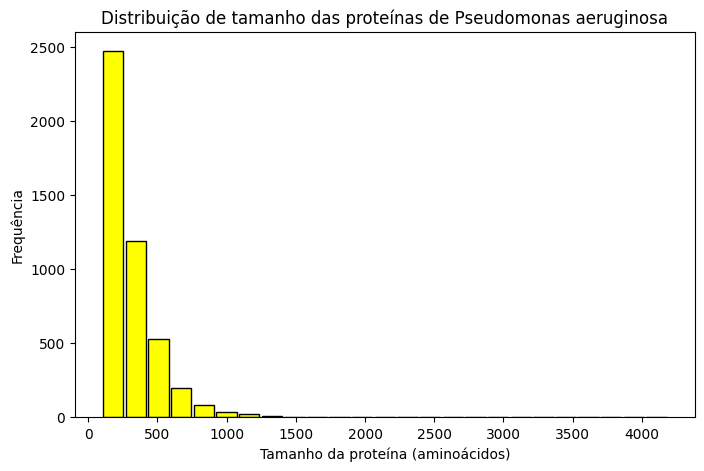

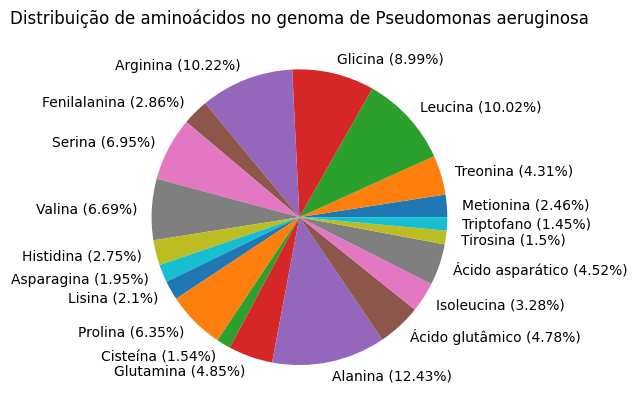

(None, None, None)

In [59]:
arquivo1 = input('Informe o nome do arquivo com o genoma da bactéria: ')
executar(arquivo1)

A célula de código abaixo pede para que o usuário informe mais três arquivos que ele deseja analisar além do primeiro arquivo que já foi analisado anteriomente. Os nomes dos arquivos devem ser escritos subsequentemente, separados por 1 (um) espaço, conforme e seguinte estrutura: **nome_arquivo2.fna         nome_arquivo3.fna  nome_arquivo4.fna** . Por exemplo, execute a célula de código abaixo e insira os nomes dos seguintes arquivos: **genoma_gonorrhoeae.fna genoma_pneumoniae.fna genoma_tuberculosis.fna** 

*Que tal compararmos o conteúdo GC e a distribuição de aminoácidos com os de outras bactérias? Execute a célula abaixo e insira o nome de mais três arquivos.*

Informe mais 3 nomes de arquivos de DNAs que você deseja comparar. Os nomes devem estar separados por espaço:  genoma_gonorrhoeae.fna genoma_pneumoniae.fna genoma_tuberculosis.fna


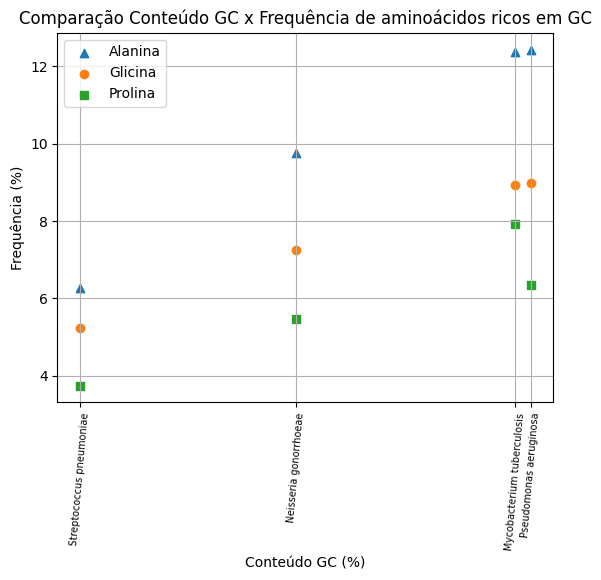

In [60]:
arquivo2, arquivo3, arquivo4 = input(f'Informe mais 3 nomes de arquivos de DNAs que você deseja comparar. Os nomes devem estar separados por espaço: ').split()
plotar_GC_vs_aminoacido(arquivo1, arquivo2, arquivo3, arquivo4)

## 5 Resultados

O projeto foi desenvolvido com o intuito de introduzir conceitos da bioinformática que envolvem a análise de sequências nucleotídicas e de aminoácidos de genomas bacterianos reias. Dessa forma, é possível vizualizar métricas básicas importantes para o aprendizado da bioinformática, abrangendo conteúdos tanto das Ciências de Dados quanto das Ciências da Vida. Nesse sentido, as ferramentas elaboradas por esse projeto podem ser utilizadas por estudantes ingressantes no curso de Bacharelado em Ciência e Tecnologia para elucidar conceitos introdutórios de biologia molecular e programação básica em *Python* de forma interdisciplinar.

Em relação ao teste das ferramentas do projeto, contanto que o usuário siga as instruções condizentes com as limitações impostas, todos os gráficos e análises serão executados com êxito. A vizualização dos dados em gráficos é essencial para compreender o DNA bacteriano e os processos biológicos que o envolvem de forma simples, fortalecendo, simultaneamente, capacidades de programação e elaboração de algoritmos em *Python*.

## 6 Conclusão

Conclui-se que o projeto obteve boa eficiência em termos de introdução à bioinformática e cumpre sua função em analisar o DNA bacteriano dentro de suas limitações, oferecendo interpretações analíticas de gráficos pertinentes para a compreensão de um genoma. Quanto ao código desenvolvido, observa-se um estruturação menos elegante, mas mais intuitiva, correspondente a necessidade de compreender o passo a passo da manipulação de listas, dicionários e strings quando o número de dados é muito grande. Cabe ressaltar, também, que a plotagem de gráficos segue uma configuração simples, essencial para a correlação de diferentes conhecimentos sem muita complexidade.